*Algoritmo en Profundidad*, Ejemplo de Implementaciones


In [54]:
!pip install networkx matplotlib

In [55]:
# AUTOR: Luis García
# CARRERA: Ingeniería en Computación
import networkx as nx
import matplotlib.pyplot as plt
import os

# DEFINIENDO EL GRAFO MEDIANTE UN DICCIONARIO DE PYTHON:
# PARA MEJOR COMPRENSION EL VALOR 'a': [(p, 4), (j, 15), (b, 1)],
# INDICA QUE EL VERTICE 'a' ES ADYACENTE CON 'P', CON 'j' Y CON 'b'
# CADA UNO CON SU RESPECTIVO PESO, AUNQUE EL PESO PARA HACER RECCORRIDOS EN PROFUNDIDAD
# NO ES NECESARIO, AGREGUADO PARA MOSTRAR TAMBIÉN LA IMPLEMENTACIÓN DE UN GRAFO PONDERADO

grafo = {
    "a": [("p", 4), ("j", 15), ("b", 1)],
    "b": [("a", 1), ("d", 2), ("e", 2), ("c", 3)],
    "j": [("a", 15)],
    "p": [("a", 4)],
    "d": [("b", 2), ("g", 3)],
    "e": [("b", 2), ("g", 4), ("f", 5), ("c", 2)],
    "c": [("b", 3), ("e", 2), ("f", 5), ("i", 20)],
    "g": [("d", 3), ("e", 4), ("f", 10), ("h", 1)],
    "f": [("g", 10), ("e", 5), ("c", 5)],
    "i": [("c", 20)],
    "h": [("g", 1)],
}

# Over: Voy a comentar el algoritmo para no verlo.

# # MUESTRA EL GRAFO ANTES DEL RECORRIDO
# print("Muestra el grafo antes del recorrido: \n")
# for key, lista in grafo.items():
#     print(key,lista)

# print()
# os.system("pause")

# visitados = []
# pila = []

# origen = input("Ingresa un nodo: ")
# print("\nLista de recorrido en profundidad\n")
# # Paso 1: SE COLOCA EL VÉRTICE ORIGEN EN UNA PILA
# pila.append(origen)
# # Paso 2: MIENTRAS LA PILA NO ESTE VACÍA
# while pila:
#     # paso 3: DESAPILAR UN VÉRTICE, ESTE SERÁ AHORA EL VÉRTICE ACTUAL
#     actual = pila.pop()
#     # FORMA ALTERNATIVA PARA DESAPILAR:
#     # actual = pila[-1]
#     # pila.remove(pila[-1])

#     # paso 4: SI EL VÉRTICE ACTUAL NO HA SIDO VISITADO
#     if actual not in visitados:
#         # paso 5: PROCESAR (IMPRIMIR) EL VÉRTICE ACTUAL
#         print("Vertice actual -> ", actual)
#         # paso 6: COLOCAR VÉRTICE ACTUAL EN LA LISTA DE VISITADOS
#         visitados.append(actual)
#     # paso 7: PARA CADA VÉRTICE QUE EL VÉRTICE ACTUAL TIENE COMO DESTINO, Y QUE NO HA SIDO VISITADO:
#     # APILAR EL VERTICE
#     for key, lista in grafo[actual]:
#         if key not in visitados:
#             pila.append(key)

print()
os.system("pause")

32512

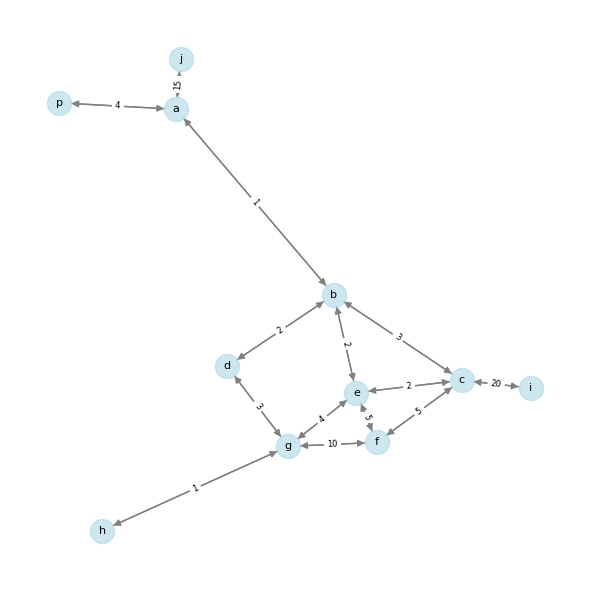

In [70]:
%matplotlib inline
# Visualizar el grafo - Sinceramente usé IA pues la intención era verlo y mentalmente pensar las búsquedas.
grafo = {
    "a": [("p", 4), ("j", 15), ("b", 1)],
    "b": [("a", 1), ("d", 2), ("e", 2), ("c", 3)],
    "j": [("a", 15)],
    "p": [("a", 4)],
    "d": [("b", 2), ("g", 3)],
    "e": [("b", 2), ("g", 4), ("f", 5), ("c", 2)],
    "c": [("b", 3), ("e", 2), ("f", 5), ("i", 20)],
    "g": [("d", 3), ("e", 4), ("f", 10), ("h", 1)],
    "f": [("g", 10), ("e", 5), ("c", 5)],
    "i": [("c", 20)],
    "h": [("g", 1)],
}

G = nx.DiGraph()

# Agregar aristas con pesos
for origen, destinos in grafo.items():
    for destino, peso in destinos:
        G.add_edge(origen, destino, weight=peso)

# Configurar el tamaño más pequeño
plt.figure(figsize=(6, 6))

# Crear el layout spring con parámetros ajustados
pos = nx.spring_layout(G, k=0.9, iterations=50)

# Dibujar los nodos más pequeños
nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                      node_size=300, alpha=0.6)

# Dibujar las aristas con flechas más pequeñas
nx.draw_networkx_edges(G, pos, edge_color='gray',
                      arrows=True, arrowsize=10)

# Agregar las etiquetas de los nodos con fuente más pequeña
nx.draw_networkx_labels(G, pos, font_size=8)

# Agregar los pesos de las aristas con fuente más pequeña
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6)

# Eliminar los ejes
plt.axis('off')

# Ajustar el layout
plt.tight_layout()

# Mostrar el grafo
plt.show()

# Algoritmos de Búsqueda

La verdad nunca entendí estos algoritmos en el curso de Estructuras de datos (Con Giovanni) y al momento de su implemenación aún no he pensado cómo hacerlos. Voy a intentar hacer ambos por mi cuenta, redescubrir la rueda.

## Pensamiento - Amplitud/Anchura

En este algoritmo, desde un punto de vista de árbol primero debe recorrer todos los hijos de un nivel para poder proceder con el siguiente, lo intentaré pensándolo a nivel de árbol e imagino el algoritmo funcionará en consecuencia para cualquier grafo.

### La revelación

Vale entonces qué pasa, para este algoritmo se debe tener una colección ordenada (lista) con los elementos que se van a recorrer linealmente.

Además, noté algo muy curioso imaginando el funcionamiento, cada que nos posicionamos en un nodo, debemos añadir todos y cada uno de sus hijos a la colección (listado) y de esta forma podemos recorrer todos los hijos de un mismo nivel de izquierda a derecha! Siempre y cuando el hijo no haya sido visto antes.

Bastante increíble, algo que pensaba era más complejo es tan elemental como ello, añadir los hijos del nodo que estoy iterando a la colección, de dicha forma se crea una cola, donde recorremos los hijos de un nivel y al bajar se iteran los hijos concatenados del siguiente nivel.

**Modifique el algoritmo anterior para que funcione como un algoritmo en Anchura**

In [71]:
# Busqueda en amplitud (intentado por mi cuenta)
cola = []
vistos = set()

def amplitud(nodo_inicial):
  cola.append(nodo_inicial)
  vistos.add(nodo_inicial)

  while cola:
    actual: str = cola.pop(0)
    hijos = grafo[actual]
    # print("\nvistos", vistos)
    print("> actual", actual)

    for hijo, peso in hijos:
      if hijo not in vistos:
        vistos.add(hijo)
        cola.append(hijo)
        print("  > append", hijo)

nodo_inicio = 'e'
amplitud(nodo_inicio)


> actual e
  > append b
  > append g
  > append f
  > append c
> actual b
  > append a
  > append d
> actual g
  > append h
> actual f
> actual c
  > append i
> actual a
  > append p
  > append j
> actual d
> actual h
> actual i
> actual p
> actual j


# Algoritmos de Búsqueda

Vale ahora vamos a intentar el algoritmo por profundidad

## Pensamiento - Amplitud/Anchura

Okay, en este entonces un nodo tiene varios hijos, no obstante, se recorren los hijos del primer nodo seleccionado hasta que no tenga más y vuelve para recorrer esos que haya dejado, hmm, a ver pienso su implementación.

### La revelación

No puede ser. Es el mismo algoritmo pero cambia algo, ocurre que claro, tenemos un nodo padre y este tendrá varios hijos, pero entonces al momento de que añadamos los hijos a recorrer pasa algo curioso, esto es que el orden realmente siempre fue relativo, no importa realmente que "visualmente" uno escoja el primero, puesto eso depende al orden de los datos tanto como lista como en el dibujo, entonces, al salir de dicho marco de ver el proceso noté algo importante.

Ocurre que, al momento de almacenar los hijos de un nodo, lo que vamos a hacer es por supuesto revisar que si no está pues no añadirlo, pero, el detalle es que, al momento que sacamos el nodo para ver sus hijos, este debe ser el último nodo simplemente porque así vamos a bajar de nivel siempre hasta que lleguemos a un tope.

Esto puesto recorremos todos los hijos de un nivel, pero pues claro está que es porque el padre necesita conocer a sus hijos, no obstante, va a seguir bajando por el último de ellos, de forma que cuando termine de bajar, no le quedará más que volver al penúltimo nodo, que es el hijo del anterior nivel que necesita seguir recorriendo, en pos-orden.

Es de esta forma que claro, funciona como una pila, porque los últimos hijos que son los que permiten bajar de nivel están al final, de forma que son los que debemos recorrer primero.

In [69]:
# Busqueda en profundidad (intento por mi cuenta).

# A cada que se recorra se añade el hijo si no está.

pila = []
vistos = set()

def profundidad(inicio: str):
  pila.append(inicio)
  vistos.add(inicio)

  while pila:
    actual = pila.pop()
    hijos = grafo[actual]
    print('> actual', actual)

    for hijo, peso in hijos:
      if hijo not in vistos:
        vistos.add(hijo)
        pila.append(hijo)
        print('  > append', hijo)

letra_inicio = 'g'
profundidad(letra_inicio)

> actual g
  > append d
  > append e
  > append f
  > append h
> actual h
> actual f
  > append c
> actual c
  > append b
  > append i
> actual i
> actual b
  > append a
> actual a
  > append p
  > append j
> actual j
> actual p
> actual e
> actual d


Increíble, por fin he entendido esta sección de las búsquedas por mi cuenta! *Niceee!*

# Markdown como código

```py
# Tiene formato de código
cero = float(0)
```


<img src="grafo.png" width="300" alt="Mi imagen">

1.   Elemento de lista ordenada
2.   Otro elemento

- Elemento de lista desordenada
- Otro elemento



In [5]:
## Código tomado de https://favtutor.com/blogs/breadth-first-search-python
graph = {
  '5' : ['3','7'],
  '3' : ['2', '4'],
  '7' : ['8'],
  '2' : [],
  '4' : ['8'],
  '8' : []
}

visited = [] # List for visited nodes.
queue = []     #Initialize a queue

def bfs(visited, graph, node): #function for BFS
  visited.append(node)
  queue.append(node)

  while queue:          # Creating loop to visit each node
    m = queue.pop(0)
    print (m, end = " ")

    for neighbour in graph[m]:
      if neighbour not in visited:
        visited.append(neighbour)
        queue.append(neighbour)

# Driver Code
print("Following is the Breadth-First Search")
bfs(visited, graph, '5')    # function calling

Following is the Breadth-First Search
5 3 7 2 4 8 

In [6]:
# Using a Python dictionary to act as an adjacency list
graph = {
  '5' : ['3','7'],
  '3' : ['2', '4'],
  '7' : ['8'],
  '2' : [],
  '4' : ['8'],
  '8' : []
}

visited = set() # Set to keep track of visited nodes of graph.

def dfs(visited, graph, node):  #function for dfs
    if node not in visited:
        print (node)
        visited.add(node)
        for neighbour in graph[node]:
            dfs(visited, graph, neighbour)

# Driver Code
print("Following is the Depth-First Search")
dfs(visited, graph, '5')

Following is the Depth-First Search
5
3
2
4
8
7
